## Block-1: Environment setup + frozen CUB model loading

Block-1.0: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Block-1.1: Imports & device

In [2]:
# Imports and device setup

import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Block-1.2: Recreate ResNet-18 for CUB-200

In [3]:
# Recreate ResNet-18 architecture for CUB-200

model = models.resnet18(weights=None)

# Replace classifier head for 200 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 200)

Block-1.3: Load frozen weights + freeze model

In [4]:
# Load frozen weights and freeze model

model_path = "/content/drive/MyDrive/Models/resnet18_cub200_frozen.pth"  # adjust if needed

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

# Freeze parameters (critical for explainability)
for param in model.parameters():
    param.requires_grad = False

model = model.to(device)
model.eval()

print("Frozen CUB model loaded and ready for explanations.")

Frozen CUB model loaded and ready for explanations.


## Block-2 — Load CUB test data + sanity-check inference

Block-2.1: ImageNet-style test transforms (CUB)

In [5]:
# CUB test transforms (ImageNet normalization)

from torchvision import transforms

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [6]:
# Load CUB test dataset

import pandas as pd
import os
from torch.utils.data import DataLoader
from PIL import Image
from torch.utils.data import Dataset

data_root = "/content/drive/MyDrive/CUB_200_2011"

# Reload metadata (safe + explicit)
images_df = pd.read_csv(
    os.path.join(data_root, "images.txt"),
    sep=" ",
    names=["img_id", "filepath"]
)

labels_df = pd.read_csv(
    os.path.join(data_root, "image_class_labels.txt"),
    sep=" ",
    names=["img_id", "class_id"]
)

split_df = pd.read_csv(
    os.path.join(data_root, "train_test_split.txt"),
    sep=" ",
    names=["img_id", "is_train"]
)

cub_df = images_df.merge(labels_df, on="img_id").merge(split_df, on="img_id")

test_df = cub_df[cub_df["is_train"] == 0]

class CUBDataset(Dataset):
    def __init__(self, dataframe, data_root, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_root, "images", row["filepath"])
        image = Image.open(img_path).convert("RGB")
        label = row["class_id"] - 1

        if self.transform:
            image = self.transform(image)

        return image, label


test_dataset = CUBDataset(test_df, data_root, transform=transform_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0   # important for Drive
)

print("CUB test dataset loaded.")

CUB test dataset loaded.


Block-2.3: Load class names

In [7]:
# Load CUB class names

classes_df = pd.read_csv(
    os.path.join(data_root, "classes.txt"),
    sep=" ",
    names=["class_id", "class_name"]
)

classes = classes_df["class_name"].tolist()

Block-2.4: Sanity-check inference

In [8]:
# Sanity-check inference

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

for i in range(len(images)):
    print(
        f"True: {classes[labels[i]]:>30s} | "
        f"Predicted: {classes[preds[i]]}"
    )

True:               174.Palm_Warbler | Predicted: 119.Field_Sparrow
True:                  198.Rock_Wren | Predicted: 074.Florida_Jay
True:           093.Clark_Nutcracker | Predicted: 093.Clark_Nutcracker
True:              100.Brown_Pelican | Predicted: 101.White_Pelican
True:               135.Bank_Swallow | Predicted: 079.Belted_Kingfisher
True:      157.Yellow_throated_Vireo | Predicted: 157.Yellow_throated_Vireo
True:  043.Yellow_bellied_Flycatcher | Predicted: 152.Blue_headed_Vireo
True:           116.Chipping_Sparrow | Predicted: 116.Chipping_Sparrow


## Block-3 — Grad-CAM hook registration

In [9]:
# Hooks for explanation attack

activations = {}
gradients = {}

def forward_hook_attack(module, input, output):
    activations["value"] = output  # NO detach

def backward_hook_attack(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]  # NO detach

# Target layer
target_layer = model.layer4[-1].conv2

# Register attack hooks (fresh)
forward_handle = target_layer.register_forward_hook(forward_hook_attack)
backward_handle = target_layer.register_backward_hook(backward_hook_attack)

print("Attack hooks registered (gradients preserved).")

Attack hooks registered (gradients preserved).


## Block-4 — Compute Grad-CAM for ONE correctly classified CUB image

Block-4.1: Get one correctly classified sample

In [10]:
# Select one correctly classified test image

import torch
import torch.nn.functional as F

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
preds = torch.argmax(outputs, dim=1)

idx = None
for i in range(len(images)):
    if preds[i] == labels[i]:
        idx = i
        break

assert idx is not None, "No correctly classified sample found."

print("Using sample index:", idx)
print("Class:", classes[labels[idx]])

Using sample index: 0
Class: 018.Spotted_Catbird


Block-4.2: Enable gradients on input + backward

In [11]:
# Forward + backward for Grad-CAM

input_image = images[idx].unsqueeze(0)
input_image.requires_grad_(True)   # 🔴 REQUIRED

target_class = preds[idx].item()

# Clear old gradients
model.zero_grad()

# Forward pass
output = model(input_image)

# Backward ONLY on target class logit
class_score = output[0, target_class]
class_score.backward()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Block-4.3: Compute Grad-CAM (7×7)

In [12]:
# Grad-CAM computation (no upsampling yet)

A = activations["value"]      # [1, 512, 7, 7]
G = gradients["value"]        # [1, 512, 7, 7]

# Channel-wise weights
weights = G.mean(dim=(2, 3), keepdim=True)

# Weighted sum + ReLU
grad_cam = F.relu((weights * A).sum(dim=1)).squeeze()  # [7, 7]

# Normalize to [0, 1]
grad_cam -= grad_cam.min()
grad_cam /= grad_cam.max() + 1e-8

print("Grad-CAM computed.")
print("Grad-CAM shape:", grad_cam.shape)

Grad-CAM computed.
Grad-CAM shape: torch.Size([7, 7])


## Block-5 — Upsample Grad-CAM and Overlay on the CUB Image

Block-5.1: Upsample Grad-CAM to input resolution

In [13]:
# Upsample Grad-CAM to 224x224

import torch.nn.functional as F

grad_cam_upsampled = F.interpolate(
    grad_cam.unsqueeze(0).unsqueeze(0),  # [1,1,7,7]
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().detach().cpu().numpy()

print("Upsampled Grad-CAM shape:", grad_cam_upsampled.shape)

Upsampled Grad-CAM shape: (224, 224)


Block-5.2: De-normalize input image (ImageNet stats)

In [14]:
# De-normalize input image for visualization

import numpy as np

img = input_image.squeeze().cpu().detach().numpy()  # [3,224,224]

mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

img = (img * std) + mean
img = np.clip(img, 0, 1)
img = np.transpose(img, (1, 2, 0))  # CHW → HWC

Block-5.3: Overlay Grad-CAM on image

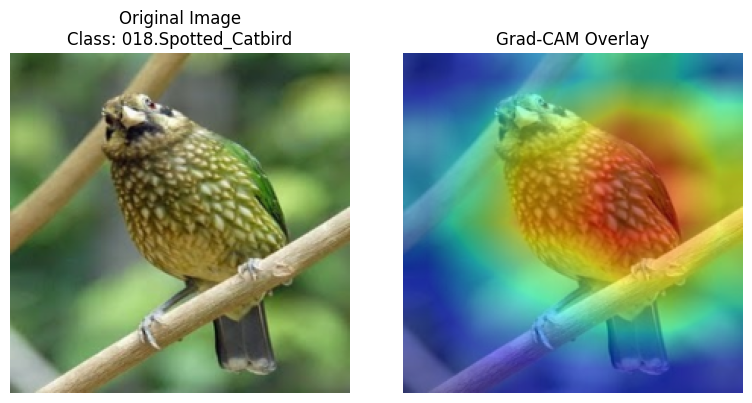

In [15]:
# Visualization — original vs Grad-CAM overlay

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original Image\nClass: {classes[target_class]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(grad_cam_upsampled, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Block-6 — Integrated Gradients (IG) for CUB

Block-6.1: Integrated Gradients function

In [16]:
# Integrated Gradients implementation

def integrated_gradients(
    model,
    input_image,
    target_class,
    baseline=None,
    steps=50
):
    """
    Computes Integrated Gradients for a single input image.
    """
    if baseline is None:
        baseline = torch.zeros_like(input_image)

    grads = []

    for i in range(steps + 1):
        alpha = float(i) / steps

        # 🔴 Make x a LEAF tensor
        x = baseline + alpha * (input_image - baseline)
        x = x.detach()
        x.requires_grad_(True)

        model.zero_grad()

        out = model(x)
        out[0, target_class].backward()

        grads.append(x.grad.detach())

    # Average gradients along the path
    avg_grads = torch.mean(torch.stack(grads), dim=0)

    # Integrated gradients
    ig = (input_image - baseline) * avg_grads
    return ig

Block-6.2: Compute IG for the same image

In [17]:
# Compute Integrated Gradients

baseline = torch.zeros_like(input_image)

ig = integrated_gradients(
    model=model,
    input_image=input_image,
    target_class=target_class,
    baseline=baseline,
    steps=50
)

# Convert to attribution map (sum over channels)
ig_map = ig.abs().sum(dim=1).squeeze()

# Normalize to [0,1]
ig_map -= ig_map.min()
ig_map /= ig_map.max() + 1e-8

print("Integrated Gradients computed.")
print("IG map shape:", ig_map.shape)

Integrated Gradients computed.
IG map shape: torch.Size([224, 224])


Block-6.3: Visualize IG overlay

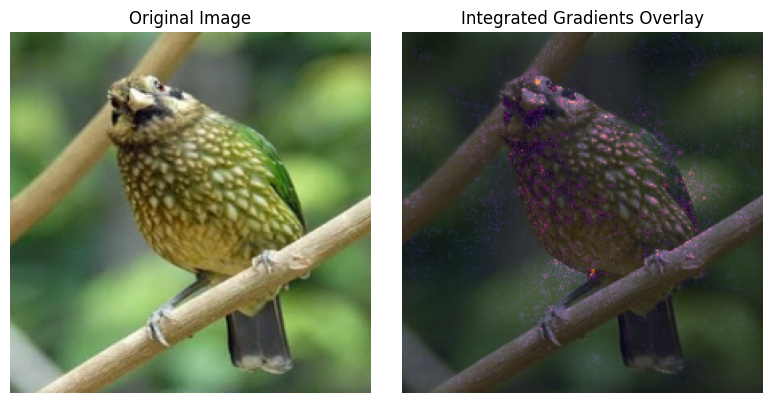

In [18]:
# Visualize Integrated Gradients

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(ig_map.detach().cpu().numpy(), cmap="inferno", alpha=0.6)
plt.title("Integrated Gradients Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Block-7 — Side-by-Side Comparison: Grad-CAM vs Integrated Gradients

Block-7.1: Side-by-side visualization

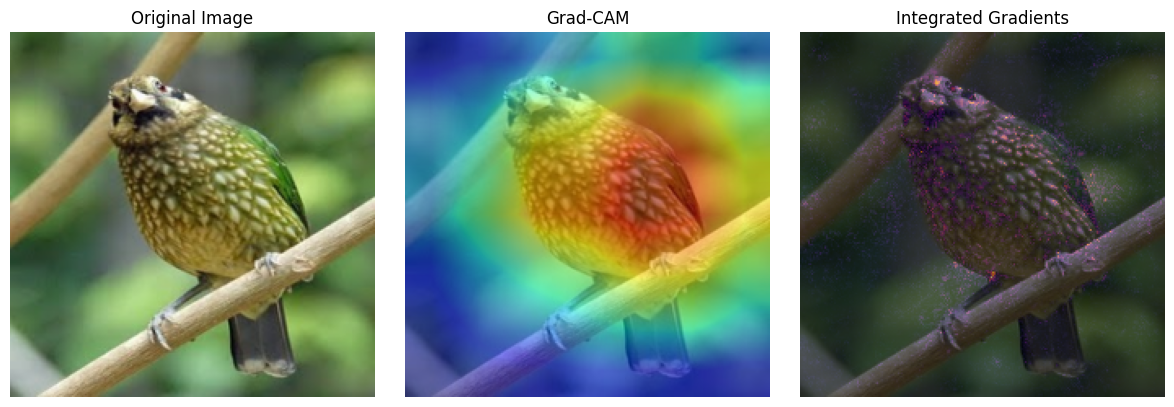

In [19]:
# Grad-CAM vs Integrated Gradients comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Grad-CAM
plt.subplot(1, 3, 2)
plt.imshow(img)
plt.imshow(grad_cam_upsampled, cmap="jet", alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")

# Integrated Gradients
plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(ig_map.detach().cpu().numpy(), cmap="inferno", alpha=0.6)
plt.title("Integrated Gradients")
plt.axis("off")

plt.tight_layout()
plt.show()

## Block-8 — Hard-Constrained Explanation Attack (Setup + Baseline)

Block-8.1: Lock original input & prediction

In [20]:
# Lock original image and prediction (hard constraint)

# Reuse the previously selected correct sample
x = input_image.detach()        # [1, 3, 224, 224]
y = target_class                # fixed predicted class

print("Locked class:", classes[y])

Locked class: 018.Spotted_Catbird


Block-8.2: Compute baseline Grad-CAM H(x)

In [21]:
# Baseline Grad-CAM computation

x_base = x.clone().detach().requires_grad_(True)
model.zero_grad()

out = model(x_base)
out[0, y].backward()

A_base = activations["value"]
G_base = gradients["value"]

w_base = G_base.mean(dim=(2, 3), keepdim=True)
cam_base = torch.relu((w_base * A_base).sum(dim=1))

# Normalize
cam_base -= cam_base.min()
cam_base /= cam_base.max() + 1e-8

cam_base = cam_base.detach()

print("Baseline Grad-CAM computed.")

Baseline Grad-CAM computed.


Block-8.3: Compute baseline Integrated Gradients I(x)

In [22]:
# Baseline Integrated Gradients

baseline = torch.zeros_like(x)

ig_base = integrated_gradients(
    model=model,
    input_image=x,
    target_class=y,
    baseline=baseline,
    steps=50
)

ig_base_map = ig_base.abs().sum(dim=1)
ig_base_map -= ig_base_map.min()
ig_base_map /= ig_base_map.max() + 1e-8

ig_base_map = ig_base_map.detach()

print("Baseline Integrated Gradients computed.")

Baseline Integrated Gradients computed.


Block-8.4: Initialize adversarial candidate

In [23]:
# Initialize adversarial image

x_adv = x.clone().detach()
accepted_steps = 0

print("Attack initialized.")

Attack initialized.


## Block-9 — Hard-Constrained Explanation Attack Loop

Block-9.1: Attack hyperparameters

In [24]:
# Attack hyperparameters

epsilon = 0.7      # max L-infinity perturbation
step_size = 0.01    # step size
steps = 30           # number of attack iterations

Block-9.2: Hard-constrained attack loop (Grad-CAM based)

In [25]:
# Hard-constrained explanation attack loop (Grad-CAM)

import torch.nn.functional as F

for step in range(steps):

    x_candidate = x_adv.clone().detach().requires_grad_(True)
    model.zero_grad()

    # Forward pass
    logits = model(x_candidate)
    pred = torch.argmax(logits, dim=1).item()

    # Hard prediction constraint
    if pred != y:
        print(f"Step {step+1}: rejected (prediction changed)")
        continue

    # Backward ONLY on class logit
    logits[0, y].backward()

    # Current Grad-CAM
    A = activations["value"]
    G = gradients["value"]
    w = G.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * A).sum(dim=1))

    cam -= cam.min()
    cam /= cam.max() + 1e-8

    # Explanation divergence (L2, no backward)
    cam_loss = torch.norm(cam - cam_base, p=2)

    # Gradient ascent on input
    with torch.no_grad():
        x_new = x_candidate + step_size * x_candidate.grad.sign()

        # ε-ball projection
        x_new = torch.max(torch.min(x_new, x + epsilon), x - epsilon)

        # valid pixel range (normalized space)
        x_new = torch.clamp(x_new, -3, 3)

    # Check prediction again
    new_pred = torch.argmax(model(x_new), dim=1).item()

    if new_pred == y:
        x_adv = x_new.detach()
        accepted_steps += 1
        print(f"Step {step+1}: accepted | CAM loss = {cam_loss.item():.4f}")
    else:
        print(f"Step {step+1}: rejected (boundary crossing)")

Step 1: accepted | CAM loss = 0.0000
Step 2: accepted | CAM loss = 0.4036
Step 3: accepted | CAM loss = 0.5626
Step 4: accepted | CAM loss = 0.6717
Step 5: accepted | CAM loss = 0.7379
Step 6: accepted | CAM loss = 0.8148
Step 7: accepted | CAM loss = 0.8836
Step 8: accepted | CAM loss = 0.9318
Step 9: accepted | CAM loss = 1.0407
Step 10: accepted | CAM loss = 1.0000
Step 11: accepted | CAM loss = 1.1180
Step 12: accepted | CAM loss = 1.0894
Step 13: accepted | CAM loss = 1.1566
Step 14: accepted | CAM loss = 1.1468
Step 15: accepted | CAM loss = 1.1726
Step 16: accepted | CAM loss = 1.1556
Step 17: accepted | CAM loss = 1.1845
Step 18: accepted | CAM loss = 1.2090
Step 19: accepted | CAM loss = 1.2145
Step 20: accepted | CAM loss = 1.2332
Step 21: accepted | CAM loss = 1.2228
Step 22: accepted | CAM loss = 1.2600
Step 23: accepted | CAM loss = 1.2382
Step 24: accepted | CAM loss = 1.2872
Step 25: accepted | CAM loss = 1.2538
Step 26: accepted | CAM loss = 1.3061
Step 27: accepted | C

Block-9.3: Attack summary

In [26]:
print(f"\nAttack complete.")
print(f"Accepted steps: {accepted_steps}/{steps}")


Attack complete.
Accepted steps: 30/30


## Block-10 — Final Visualization & Sanity Checks

Block-10 — Final Visualization & Sanity Checks

In [27]:
# De-normalization helper (ImageNet)

import numpy as np

def denormalize(img_tensor):
    img = img_tensor.squeeze().cpu().detach().numpy()
    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    return np.transpose(img, (1, 2, 0))  # CHW → HWC

Block-10.2: Recompute baseline & adversarial Grad-CAM

In [28]:
# Baseline Grad-CAM (for visualization)

x_base_vis = x.clone().detach().requires_grad_(True)
model.zero_grad()
out = model(x_base_vis)
out[0, y].backward()

A = activations["value"]
G = gradients["value"]
w = G.mean(dim=(2,3), keepdim=True)

cam_base_vis = torch.relu((w * A).sum(dim=1))
cam_base_vis -= cam_base_vis.min()
cam_base_vis /= cam_base_vis.max() + 1e-8

cam_base_vis = F.interpolate(
    cam_base_vis.unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().detach().cpu().numpy()


# Adversarial Grad-CAM
x_adv_vis = x_adv.clone().detach().requires_grad_(True)
model.zero_grad()
out_adv = model(x_adv_vis)
out_adv[0, y].backward()

A_adv = activations["value"]
G_adv = gradients["value"]
w_adv = G_adv.mean(dim=(2,3), keepdim=True)

cam_adv_vis = torch.relu((w_adv * A_adv).sum(dim=1))
cam_adv_vis -= cam_adv_vis.min()
cam_adv_vis /= cam_adv_vis.max() + 1e-8

cam_adv_vis = F.interpolate(
    cam_adv_vis.unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().detach().cpu().numpy()

Block-10.3: Recompute baseline & adversarial IG

In [29]:
# Integrated Gradients (baseline vs adversarial)

ig_base = integrated_gradients(model, x, y, baseline=torch.zeros_like(x), steps=50)
ig_adv  = integrated_gradients(model, x_adv, y, baseline=torch.zeros_like(x_adv), steps=50)

ig_base_map = ig_base.abs().sum(dim=1)
ig_adv_map  = ig_adv.abs().sum(dim=1)

ig_base_map -= ig_base_map.min()
ig_base_map /= ig_base_map.max() + 1e-8

ig_adv_map -= ig_adv_map.min()
ig_adv_map /= ig_adv_map.max() + 1e-8

ig_base_map = ig_base_map.squeeze().detach().cpu().numpy()
ig_adv_map  = ig_adv_map.squeeze().detach().cpu().numpy()

Block-10.4: Prediction sanity check

In [30]:
# Prediction preservation check

pred_orig = torch.argmax(model(x)).item()
pred_adv  = torch.argmax(model(x_adv)).item()

print("Original prediction:", classes[pred_orig])
print("Adversarial prediction:", classes[pred_adv])
print("Prediction preserved:", pred_orig == pred_adv)

Original prediction: 018.Spotted_Catbird
Adversarial prediction: 018.Spotted_Catbird
Prediction preserved: True


Block-10.5: Final visualization

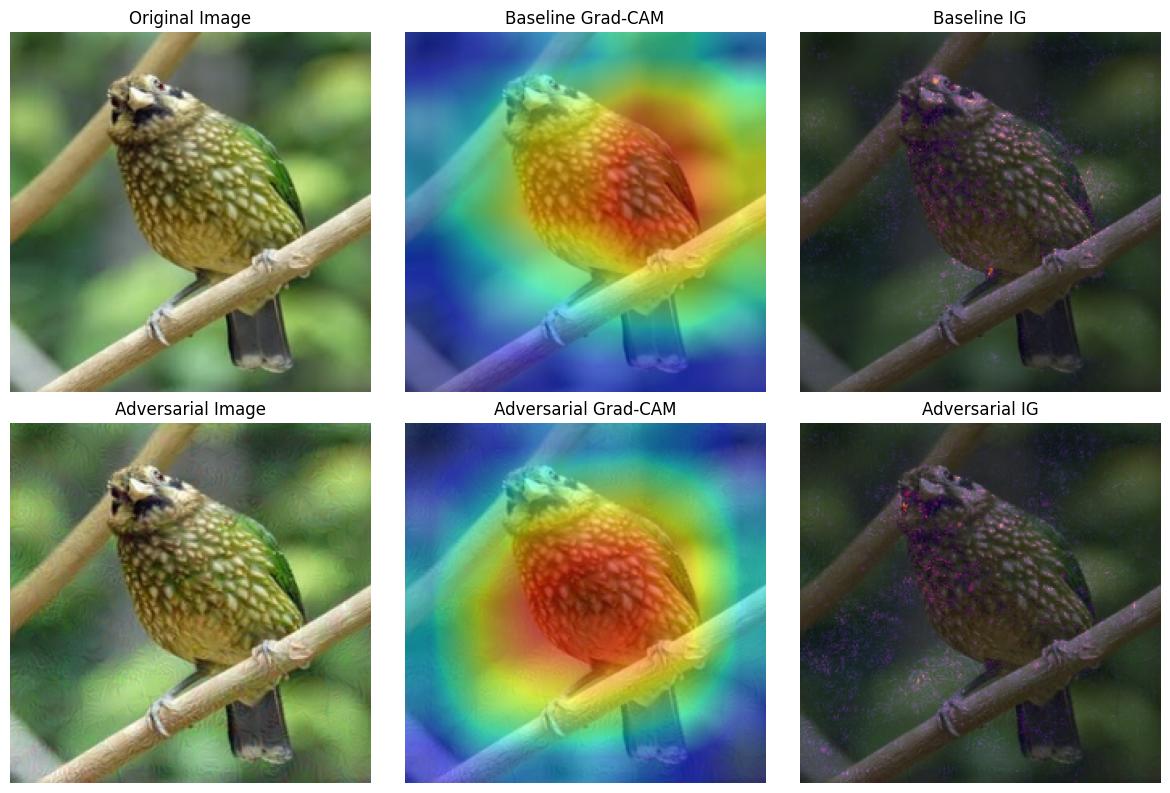

In [31]:
# Final comparison plot

import matplotlib.pyplot as plt

img_orig = denormalize(x)
img_adv  = denormalize(x_adv)

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.imshow(img_orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img_orig)
plt.imshow(cam_base_vis, cmap="jet", alpha=0.5)
plt.title("Baseline Grad-CAM")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(img_orig)
plt.imshow(ig_base_map, cmap="inferno", alpha=0.6)
plt.title("Baseline IG")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img_adv)
plt.title("Adversarial Image")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(img_adv)
plt.imshow(cam_adv_vis, cmap="jet", alpha=0.5)
plt.title("Adversarial Grad-CAM")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(img_adv)
plt.imshow(ig_adv_map, cmap="inferno", alpha=0.6)
plt.title("Adversarial IG")
plt.axis("off")

plt.tight_layout()
plt.show()

Grad-CAM Difference Heatmap

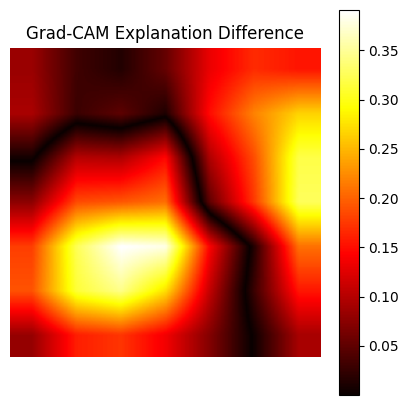

In [32]:
# Grad-CAM difference heatmap (|H(x_adv) - H(x)|)

cam_diff_map = np.abs(cam_adv_vis - cam_base_vis)

plt.figure(figsize=(5,5))
plt.imshow(cam_diff_map, cmap="hot")
plt.colorbar()
plt.title("Grad-CAM Explanation Difference")
plt.axis("off")
plt.show()

Integrated Gradients Difference Heatmap

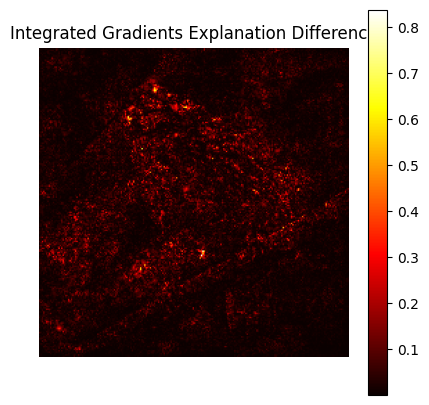

In [33]:
# Integrated Gradients difference heatmap (|I(x_adv) - I(x)|)

ig_diff_map = np.abs(ig_adv_map - ig_base_map)

plt.figure(figsize=(5,5))
plt.imshow(ig_diff_map, cmap="hot")
plt.colorbar()
plt.title("Integrated Gradients Explanation Difference")
plt.axis("off")
plt.show()

## Block-11 — Quantitative Explanation Divergence Metrics

Block-11.1: Grad-CAM divergence metrics

In [34]:
# Grad-CAM divergence metrics (L2 + Cosine + SSIM)

import numpy as np
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F

# Native 7x7 CAMs
cam_base_7 = cam_base.squeeze().detach().cpu().numpy()
cam_adv_7  = cam.squeeze().detach().cpu().numpy()

# Flatten for L2 / cosine
cam_base_flat = cam_base_7.flatten()
cam_adv_flat  = cam_adv_7.flatten()

# L2 distance
cam_l2 = np.linalg.norm(cam_base_flat - cam_adv_flat)

# Cosine distance
cam_cosine = 1 - (
    np.dot(cam_base_flat, cam_adv_flat) /
    (np.linalg.norm(cam_base_flat) * np.linalg.norm(cam_adv_flat) + 1e-8)
)

# Upsample to 224x224 for SSIM
cam_base_up = F.interpolate(
    torch.tensor(cam_base_7).unsqueeze(0).unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

cam_adv_up = F.interpolate(
    torch.tensor(cam_adv_7).unsqueeze(0).unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

# SSIM
cam_ssim = ssim(
    cam_base_up,
    cam_adv_up,
    data_range=cam_adv_up.max() - cam_adv_up.min()
)

print("Grad-CAM Divergence Metrics")
print("---------------------------")
print(f"L2 Distance     : {cam_l2:.4f}")
print(f"Cosine Distance: {cam_cosine:.4f}")
print(f"SSIM            : {cam_ssim:.4f}")

Grad-CAM Divergence Metrics
---------------------------
L2 Distance     : 1.3365
Cosine Distance: 0.0667
SSIM            : 0.8176


Block-11.2: Integrated Gradients divergence metrics

In [35]:
# Integrated Gradients divergence metrics

from skimage.metrics import structural_similarity as ssim

# Flatten IG maps
ig_base_flat = ig_base_map.flatten()
ig_adv_flat  = ig_adv_map.flatten()

# L2 distance
ig_l2 = np.linalg.norm(ig_base_flat - ig_adv_flat)

# Cosine distance
ig_cosine = 1 - (
    np.dot(ig_base_flat, ig_adv_flat) /
    (np.linalg.norm(ig_base_flat) * np.linalg.norm(ig_adv_flat) + 1e-8)
)

# SSIM (treat IG maps as grayscale images)
ig_ssim = ssim(
    ig_base_map,
    ig_adv_map,
    data_range=ig_adv_map.max() - ig_adv_map.min()
)

print("\nIntegrated Gradients Divergence Metrics")
print("--------------------------------------")
print(f"L2 Distance        : {ig_l2:.4f}")
print(f"Cosine Distance   : {ig_cosine:.4f}")
print(f"SSIM (higher=similar): {ig_ssim:.4f}")


Integrated Gradients Divergence Metrics
--------------------------------------
L2 Distance        : 11.9858
Cosine Distance   : 0.3135
SSIM (higher=similar): 0.5196
